# Commande RST d'un double intégrateur


Ce notebook synthétise et simule un correcteur **RST polynomial** pour le modèle de **balle sur poutre**.

### Principe du correcteur RST (2-DDL)

Le correcteur RST est un régulateur à **deux degrés de liberté** (2-DDL) dont la loi de commande s'écrit :

$$S(z)\,u[k] = T(z)\,r[k] - R(z)\,y[k]$$

- $R(z)$ agit sur la mesure $y$  — fixe les pôles de la boucle fermée.
- $S(z)$ est le dénominateur du correcteur — peut contenir un facteur $(z-1)$ pour l'action intégrale.
- $T(z)$ agit sur la consigne $r$ — ajuste le gain de poursuite.

Les polynômes $R$, $S$, $T$ sont calculés par **résolution de l'équation diophantienne** :

$$A(z)\,S(z) + B(z)\,R(z) = A_m(z)\,A_0(z)$$

où $A_m$ fixe la dynamique désirée et $A_0$ un polynôme observateur plus rapide.

**Avantage par rapport au PID :** le placement de pôles est exact, et l'action intégrale est intégrée structurellement dans $S$ sans créer un triple pole (z=1).

In [66]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel
from Models.BallBeam.NonlinearDynamics import NonlinearBallBeamModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim
from Simulation.simulation import NonLinearHybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Configuration de la simulation:


T est le temps total de simulation et dt est le temps d'échantillonage du correcteur

In [67]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [68]:
X_0 = np.array([[0],[0]])                              # état initial
double_int = TransferFunctionModel(ballbeam_config)    # instance de TransferFunctionModel
Double_int_sim = TFSimulator(double_int.Tf_dis, X_0)   # simulateur de fonctions de transfert discrètes
double_int_NL =NonlinearBallBeamModel(ballbeam_config) # pour la simulation hybride non lineaire
double_int_simNL=NonLinearHybridSim(double_int_NL,ballbeam_config)
A = double_int.Tf_dis.den_list[0][0]                   # extraction du dénominateur A(z)
B = double_int.Tf_dis.num_list[0][0]                   # extraction du numérateur B(z)

In [69]:
### affichage 
print(double_int.Tf_cont)
print(double_int.Tf_dis)
print("Poles discrets de la FT=>",double_int.Tf_dis.poles())

<TransferFunction>: sys[75]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[75]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1
Poles discrets de la FT=> [1.+6.68896751e-09j 1.-6.68896751e-09j]


### Modèle de référence $A_m$

La fonction de transfert désirée est un **second ordre continu** caractérisé par $\omega_n$ (fréquence propre) et $\zeta$ (amortissement), discrétisé par correspondance de pôles $z_p = e^{s_p T_s}$.

Le gain statique $y(t\rightarrow \infty)$ de $T_f^\text{des}$ doit être 1 ce qui garantit le suivi sans erreur de l'échelon.

In [70]:
omega0 = 2# fréquence propre désirée [rad/s]
zeta   = 0.70   # amortissement désiré

omega_carr = omega0 * omega0
Am_s = [(1/omega_carr), (2.0*zeta/omega0), 1.0]
Am_d = np.poly(np.exp(np.roots(Am_s) * ballbeam_config.dt))

Bm = sum(Am_d)
Tf_des = ct.tf(Bm, Am_d, ballbeam_config.dt)

In [71]:
### affichage
print(Tf_des)
print("s poles:", np.roots(Am_s))
print("z poles:", np.roots(Am_d))
print("radius:", np.abs(np.roots(Am_d)))
print(Tf_des.dcgain())

<TransferFunction>: sys[77]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

        0.009324
  ---------------------
  z^2 - 1.86 z + 0.8694
s poles: [-1.4+1.42828569j -1.4-1.42828569j]
z poles: [0.93001723+0.06652965j 0.93001723-0.06652965j]
radius: [0.93239382 0.93239382]
1.0


In [72]:
## réponse inditielle de la fonction de transfert calculée par la librairie
t = np.arange( 0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(Tf_des, t)


In [82]:
A0 = np.array([1, -0.50])   # pôle observateur à z=0.70 — doit être PLUS RAPIDE que les pôles dominants

### Synthèse du correcteur RST

`Compute_Denominator_Matching_RST` résout l'**équation diophantienne** :

$$A(z)\,S(z) + B(z)\,R(z) = A_m(z)\cdot A_0(z)$$

Le membre de droite contient les pôles désirés ($A_m$) **et** les pôles de l'observateur ($A_0$). $T$ est ensuite calculé pour que le gain statique de la boucle fermée soit unitaire.

**Rôle de `Integrator=True` :** force $S(z) = (z-1)\,\tilde{S}(z)$, ce qui place un pôle de boucle ouverte à $z = 1$. Cela garantit que $G_d(1) = 0$ (rejet exact des perturbations constantes) sans modifier la dynamique de poursuite. Sans cette option, une perturbation constante laisserait une erreur statique permanente.

In [83]:
Am_d_total = np.convolve(Am_d, A0)   # polynôme cible total : A_m avec pôle A0 inclus (degré 3)
S, R, T, H_cl = computeRST.Compute_Denominator_Matching_RST(Am_d_total, double_int.Tf_dis, True)


--- RST synthesis complete ---
S: [ 0.69926113 -0.69926113]
R: [ 1145.67188999 -2144.72356738  1007.93147116]
T: [8.87979376]

Exact closed-loop transfer function enforced by R,S,T:
Numerator coefficients: [0.00233095 0.00233095]
Denominator coefficients: [ 1.         -2.36003445  1.79937546 -0.43467912]
<TransferFunction>: sys[95]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

        0.002331 z + 0.002331
  ---------------------------------
  z^3 - 2.36 z^2 + 1.799 z - 0.4347
Closed-loop DC gain: 1.0
Closed-loop poles (z): [0.93001723+0.06652965j 0.93001723-0.06652965j 0.5       +0.j        ]
Pole radii:            [0.93239382 0.93239382 0.5       ]


### Vérification de la synthèse

Après la synthèse, contrôler les trois points suivants :

1. **Gain statique de $H_\text{cl}$ = 1,0** — confirme que la consigne est atteinte sans erreur statique de poursuite.
2. **Tous les rayons des pôles < 1** — confirme la stabilité de la boucle fermée (pôles dans le cercle unité).
3. **$H_\text{cl}$ est d'ordre 3, pas 2** — les pôles affichés incluent ceux de $A_m$ *et* de $A_0$. La réponse simulée suit donc $H_\text{cl}$ (avec le pôle $A_0$), et non $T_f^\text{des}$ (second ordre seul).

### Marges de stabilité

La boucle ouverte est $L(z) = B(z)\,R(z)\,/\,\bigl[A(z)\,S(z)\bigr]$.


In [84]:
L_rst = double_int.Tf_dis * ct.tf(np.squeeze(R.num[0][0]), np.squeeze(S.num[0][0]), ballbeam_config.dt)
metrics = Metrics()
metrics.Stability(L_rst)

Gain margin:   -21.9 dB  (×0.08)
Phase margin:  80.9°


### Simulation
On crée une instance du controleur RST initialisé avec les polynomes R,S,T et on utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [85]:
rst_controller = RSTController(R, S, T)
logger_rst = SimLog()

reference = 1.0
y_0 = 0.0

logger_rst = run_discrete_control(Double_int_sim, rst_controller, ballbeam_config, reference, y_0, logger_rst, True, True)

### Métriques de performance

Dépassement, temps de montée (10 %→90 %) et temps d'établissement (bande ±10 %) calculés sur la phase de suivi de consigne (avant perturbation).

In [86]:
metrics.response_data(logger_rst, reference)

Dépassement :          5.3 %
Temps de montée :      0.950 s  (10 %→90 %)
Temps d'établissement :     1.250 s  (bande ±10 %)


### Rejet de perturbation

La fonction de transfert **perturbation → sortie** est :

$$F_p(z) = \frac{B(z)\,S(z)}{A(z)\,S(z) + B(z)\,R(z)}$$

Avec `Integrator=True`, $S(z)$ contient le facteur $(z-1)$, donc $S(1) = 0$, ce qui force $G_d(1) = 0$ : **la sortie retourne exactement à la consigne après une perturbation constante**, quelle qu'en soit l'amplitude.

Le tracé ci-dessous confirme que la réponse indicielle de $G_d$ converge vers 0 — à comparer avec le PID ($K_i = 0$) où l'erreur statique converge vers $D/K_p \neq 0$.

In [87]:
A = np.squeeze(A)
B = np.squeeze(B)
R_arr = np.squeeze(R.num[0][0])
S_arr = np.squeeze(S.num[0][0])

num = np.polymul(B, S_arr)
den = np.trim_zeros(np.round(np.polyadd(np.polymul(A, S_arr), np.polymul(B, R_arr)), 10), 'f')

Gd = ct.tf(num, den, ballbeam_config.dt)
print(Gd)
print("DC gain Gd:", ct.dcgain(Gd))

t = np.asarray(t).flatten()
_, d_resp = ct.step_response(Gd, t)

<TransferFunction>: sys[99]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0001836 z^2 + 6.211e-16 z - 0.0001836
  ---------------------------------------
     z^3 - 2.36 z^2 + 1.799 z - 0.4347
DC gain Gd: 0.0


Affichage des trois réponses

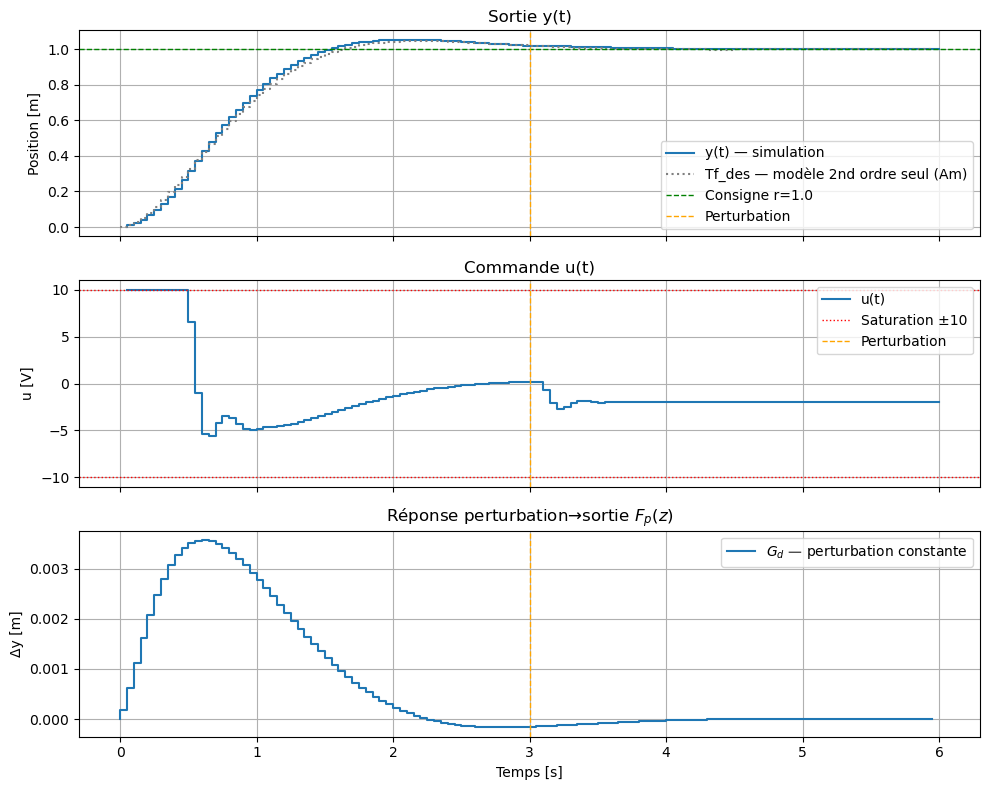

In [88]:
_, y_lib_Hcl = ct.step_response(H_cl, t)   # réponse de la boucle fermée réelle (avec pôle A0)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].step(logger_rst.t_hist, logger_rst.y_hist, label='y(t) — simulation')
ax[0].step(t, np.squeeze(y_lib),     linestyle=':',  color='gray',      label='Tf_des — modèle 2nd ordre seul (Am)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Consigne r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Perturbation')
ax[0].set_title("Sortie y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].step(logger_rst.t_hist, logger_rst.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Perturbation')
ax[1].set_title("Commande u(t)")
ax[1].set_ylabel("u [V]")
ax[1].legend()
ax[1].grid()

ax[2].step(t, d_resp, label='$G_d$ — perturbation constante')
ax[2].axvline(x=3, color='orange', linestyle='--', linewidth=1)
ax[2].set_title("Réponse perturbation→sortie $F_p(z)$")
ax[2].set_ylabel("Δy [m]")
ax[2].set_xlabel("Temps [s]")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
### pour enregister la figure décommenter ceci
#plt.savefig("Commade_PID_figure1")
plt.show()

## Simulation non linéaire

Même configuration que la simulation linéaire, mais le procédé est remplacé par la **dynamique non linéaire** de la balle sur poutre, intégrée par RK4 à $dt_\text{plant} = 1\ \text{ms}$.

Différences attendues par rapport à la simulation linéaire :
- L'initialisation du correcteur (historiques $r$, $y$ et état de $1/S$) est remise à zéro avant chaque simulation, évitant toute interférence d'état résiduel.
- La saturation à ±10 V peut provoquer un dépassement plus important en début de réponse.
- Les non-linéarités de $\sin\alpha$ restent faibles pour $|r| \lesssim 1\ \text{m}$ mais peuvent introduire un léger écart par rapport à la simulation linéaire.
- Le rejet de perturbation reste intégral (retour à zéro erreur) car l'action intégrale est dans $S$, indépendamment du modèle de procédé.

In [89]:
logger_NL=SimLog()
logger_NL=run_continuous_control_loop(double_int_simNL,rst_controller,reference,X_0,logger_NL,True,True)

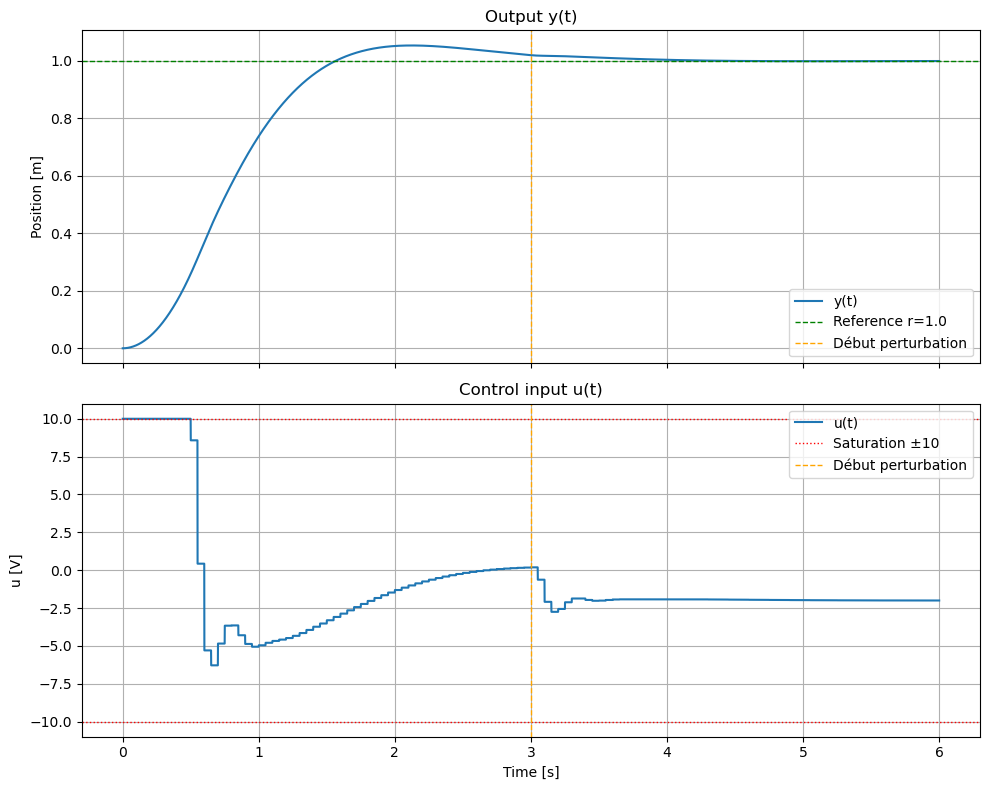

In [90]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_NL.t_hist, logger_NL.y_hist, label='y(t)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[0].set_title("Output y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_NL.t_hist, logger_NL.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [V]")
ax[1].set_xlabel("Time [s]")
ax[1].legend()
ax[1].grid()


plt.tight_layout()
### pour enregister la figure décommenter ceci
#plt.savefig("Commade_PID_figure2")
plt.show()
